# U.S. Treasury Yield-Curve PCA | 2000–2025

**Institutional-grade, Colab-ready market-risk workflow**

This notebook retrieves U.S. Treasury nominal constant-maturity yields from the Federal Reserve's H.15 release through FRED, constructs a synchronized weekly curve, and estimates economically identified **level, slope, and curvature** factors from weekly yield changes.

**Design controls**

- Official-source ingestion with retry logic, date controls, local cache, provenance timestamp, and deterministic data hash.
- Full-history core panel: **3M, 6M, 1Y, 2Y, 3Y, 5Y, 7Y, 10Y, 20Y**. The 1M series begins in 2001; the 30Y series underwent a publication discontinuity in 2002–2006, so neither is silently imputed into the 2000–2025 core panel.
- PCA is fitted to synchronized **weekly changes in basis points**, not yield levels, using the covariance matrix so tenor volatility remains economically meaningful.
- Component signs and economic labels are assigned against orthogonal curve-shape templates, eliminating arbitrary sign flips and fragile hard-coded conclusions.
- Results are challenged with reconstruction diagnostics, correlation-PCA, an 11-tenor post-2006 panel, rolling windows, and stress-week analysis.

> **Market convention note:** Treasury constant-maturity yields are a standard sovereign “risk-free proxy” for historical curve-risk analysis. They are not a production USD derivatives discount curve; collateralized derivatives are generally discounted on a SOFR/OIS framework.


## 0. Configuration

The defaults reproduce the requested 2000–2025 study. Change only the parameters in the next cell to rerun a different sample or refresh the official-source cache.


In [ ]:
from collections import OrderedDict
import base64
import gzip
from io import StringIO
from pathlib import Path
from urllib.parse import urlencode
from urllib.request import Request, urlopen
from urllib.error import HTTPError, URLError
import hashlib
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from sklearn.decomposition import PCA
from scipy.optimize import linear_sum_assignment

try:
    from IPython.display import display, Markdown, HTML
except ImportError:  # Allows non-notebook validation without changing Colab behavior.
    class Markdown(str):
        pass
    class HTML(str):
        pass
    def display(obj):
        if hasattr(obj, "to_string"):
            print(obj.to_string())
        else:
            print(obj)

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# --------------------------- USER CONTROLS ---------------------------
START_DATE = "2000-01-01"
END_DATE = "2025-12-31"
WEEKLY_RULE = "W-FRI"       # Weekly bucket; actual last joint observation date is retained.
REFRESH_DATA = False         # True forces a fresh official-source download.
RETRIES = 2
REQUEST_TIMEOUT_SECONDS = 30
ALLOW_EMBEDDED_SNAPSHOT = True  # Guaranteed 2000–2025 fallback when FRED is temporarily unavailable.
ROLLING_WINDOW_YEARS = 5
MIN_ROLLING_OBSERVATIONS = 200

FRED_SERIES = OrderedDict([
    ("DGS1MO", "1M"),
    ("DGS3MO", "3M"),
    ("DGS6MO", "6M"),
    ("DGS1", "1Y"),
    ("DGS2", "2Y"),
    ("DGS3", "3Y"),
    ("DGS5", "5Y"),
    ("DGS7", "7Y"),
    ("DGS10", "10Y"),
    ("DGS20", "20Y"),
    ("DGS30", "30Y"),
])

MATURITY_YEARS = {
    "1M": 1 / 12, "3M": 0.25, "6M": 0.50, "1Y": 1.0, "2Y": 2.0,
    "3Y": 3.0, "5Y": 5.0, "7Y": 7.0, "10Y": 10.0, "20Y": 20.0, "30Y": 30.0,
}
CORE_TENORS = ["3M", "6M", "1Y", "2Y", "3Y", "5Y", "7Y", "10Y", "20Y"]
ALL_TENORS = list(FRED_SERIES.values())
EXTENDED_PANEL_START = "2006-02-09"

BASE_DIR = Path("/content") if Path("/content").exists() else Path.cwd()
CACHE_DIR = BASE_DIR / "us_treasury_h15_cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

NAVY = "#0B1F33"
BLUE = "#1769AA"
CYAN = "#35A7C4"
GOLD = "#C99A2E"
RED = "#B23A48"
GRAY = "#66788A"
LIGHT = "#E8EEF4"
FACTOR_COLORS = [BLUE, GOLD, CYAN]

plt.rcParams.update({
    "figure.figsize": (11, 5.5),
    "figure.dpi": 120,
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "axes.edgecolor": "#CBD5DF",
    "axes.labelcolor": NAVY,
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "xtick.color": GRAY,
    "ytick.color": GRAY,
    "grid.color": "#DDE5EC",
    "grid.alpha": 0.75,
    "font.size": 10,
    "legend.frameon": False,
})

def format_table(frame, formats=None, caption=None, gradient_subset=None):
    # Colab includes Jinja2 for pandas Styler. A plain DataFrame fallback keeps
    # the analytical workflow executable in lean Python environments as well.
    try:
        styler = frame.style
    except ImportError:
        return frame
    if formats:
        styler = styler.format(formats, na_rep="—")
    if caption:
        styler = styler.set_caption(caption)
    if gradient_subset is not None:
        styler = styler.background_gradient(cmap="Blues", subset=gradient_subset)
    return styler.set_table_styles([
        {"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "700"),
                                            ("color", NAVY), ("text-align", "left"),
                                            ("padding", "8px 0")]},
        {"selector": "th", "props": [("background-color", NAVY), ("color", "white"),
                                       ("font-weight", "600"), ("padding", "7px")]},
        {"selector": "td", "props": [("padding", "7px"), ("border-bottom", "1px solid #E5EAF0")]},
    ])

print(f"Configured sample: {START_DATE} to {END_DATE} | Core tenors: {', '.join(CORE_TENORS)}")


Configured sample: 2000-01-01 to 2025-12-31 | Core tenors: 3M, 6M, 1Y, 2Y, 3Y, 5Y, 7Y, 10Y, 20Y


## 1. Official H.15 data ingestion

The loader first makes one batched request to the FRED graph CSV service, rather than eleven sequential requests. FRED identifies the **Board of Governors of the Federal Reserve System** as the source and **H.15 Selected Interest Rates** as the release.

To make the fixed 2000–2025 study reproducible when Colab or FRED temporarily times out, this notebook also contains a compressed, hash-verified snapshot of the same official extract. The output explicitly reports whether it used **live FRED**, **local cache**, or the **embedded official snapshot**. No synthetic data are introduced.


In [ ]:
FRED_CSV_ENDPOINT = "https://fred.stlouisfed.org/graph/fredgraph.csv"
BULK_CACHE_PATH = CACHE_DIR / f"H15_ALL_{START_DATE}_{END_DATE}.csv"
EMBEDDED_SNAPSHOT_SHA256 = "413b0d1241454a45d45d4bf258aa2fdf079eb4455602d102d4c3af710d306e13"
EMBEDDED_SNAPSHOT_SHAPE = (6783, 11)
EMBEDDED_H15_SNAPSHOT_B64 = (
            "..."
            "byENAA=="
)

def normalize_h15_frame(raw):
    """Normalize either a live FRED response or the embedded official snapshot."""
    frame = raw.copy()
    date_candidates = [c for c in ["observation_date", "DATE", "Date"] if c in frame.columns]
    if not date_candidates:
        raise ValueError(f"No date column found. Returned columns: {list(frame.columns)}")
    date_col = date_candidates[0]

    if set(FRED_SERIES).issubset(frame.columns):
        frame = frame.rename(columns=FRED_SERIES)
    missing = set(ALL_TENORS) - set(frame.columns)
    if missing:
        raise ValueError(f"Missing required H.15 tenors: {sorted(missing)}")

    frame = frame[[date_col] + ALL_TENORS].rename(columns={date_col: "Date"})
    frame["Date"] = pd.to_datetime(frame["Date"], errors="raise")
    for tenor in ALL_TENORS:
        frame[tenor] = pd.to_numeric(frame[tenor], errors="coerce")
    frame = frame.set_index("Date").sort_index().loc[START_DATE:END_DATE]
    frame = frame.loc[~frame.index.duplicated(keep="last")]
    frame.index.name = "Date"

    if frame.empty or frame[CORE_TENORS].dropna(how="any").empty:
        raise ValueError("H.15 data contain no complete core yield curves in the requested range.")
    return frame

def read_bulk_cache():
    cached = pd.read_csv(BULK_CACHE_PATH)
    return normalize_h15_frame(cached)

def download_fred_bulk():
    series_ids = ",".join(FRED_SERIES.keys())
    url = (
        f"{FRED_CSV_ENDPOINT}?id={series_ids}"
        f"&cosd={START_DATE}&coed={END_DATE}"
    )
    last_error = None
    for attempt in range(1, RETRIES + 1):
        try:
            request = Request(url, headers={
                "User-Agent": "Mozilla/5.0 YieldCurvePCA/2.0",
                "Accept": "text/csv,*/*;q=0.8",
                "Connection": "close",
            })
            with urlopen(request, timeout=REQUEST_TIMEOUT_SECONDS) as response:
                payload = response.read().decode("utf-8")
            frame = normalize_h15_frame(pd.read_csv(StringIO(payload)))
            frame.reset_index().to_csv(BULK_CACHE_PATH, index=False, date_format="%Y-%m-%d")
            return frame
        except (HTTPError, URLError, TimeoutError, ValueError, OSError) as exc:
            last_error = exc
            if attempt < RETRIES:
                time.sleep(1.5 * attempt)
    raise RuntimeError(f"Batched FRED request failed: {type(last_error).__name__}: {last_error}") from last_error

def load_embedded_official_snapshot():
    compressed = base64.b64decode(EMBEDDED_H15_SNAPSHOT_B64.encode("ascii"), validate=True)
    raw_bytes = gzip.decompress(compressed)
    observed_hash = hashlib.sha256(raw_bytes).hexdigest()
    if observed_hash != EMBEDDED_SNAPSHOT_SHA256:
        raise RuntimeError("Embedded official snapshot failed SHA-256 integrity validation.")
    frame = normalize_h15_frame(pd.read_csv(StringIO(raw_bytes.decode("utf-8"))))
    if frame.shape != EMBEDDED_SNAPSHOT_SHAPE:
        raise RuntimeError(
            f"Embedded snapshot shape mismatch: expected {EMBEDDED_SNAPSHOT_SHAPE}, received {frame.shape}."
        )
    return frame

def load_official_h15_curve():
    network_error = None
    if BULK_CACHE_PATH.exists() and not REFRESH_DATA:
        try:
            return read_bulk_cache(), "LOCAL_CACHE", None
        except Exception:
            BULK_CACHE_PATH.unlink(missing_ok=True)

    try:
        return download_fred_bulk(), "LIVE_FRED_BULK", None
    except Exception as exc:
        network_error = exc

    if ALLOW_EMBEDDED_SNAPSHOT:
        return load_embedded_official_snapshot(), "EMBEDDED_OFFICIAL_SNAPSHOT", network_error
    raise RuntimeError("FRED was unavailable and the embedded fallback was disabled.") from network_error

daily_yields, DATA_MODE, FRED_NETWORK_ERROR = load_official_h15_curve()
FETCHED_AT_UTC = pd.Timestamp.now(tz="UTC")
snapshot_bytes = daily_yields.to_csv(date_format="%Y-%m-%d", float_format="%.8f").encode("utf-8")
DATA_SHA256 = hashlib.sha256(snapshot_bytes).hexdigest()
fetch_status = pd.DataFrame([
    {"Series": series_id, "Tenor": tenor, "Mode": DATA_MODE}
    for series_id, tenor in FRED_SERIES.items()
])

print(f"Official data ready | rows={len(daily_yields):,} | mode={DATA_MODE}")
print(f"Runtime timestamp: {FETCHED_AT_UTC:%Y-%m-%d %H:%M UTC}")
print(f"Deterministic snapshot SHA-256: {DATA_SHA256}")
if FRED_NETWORK_ERROR is not None:
    print(
        "Live FRED was temporarily unavailable; analysis continued with the embedded, "
        f"hash-verified official snapshot. Network detail: {type(FRED_NETWORK_ERROR).__name__}."
    )
display(format_table(fetch_status, caption="Series-level ingestion status"))


Official data ready | rows=6,783 | mode=LOCAL_CACHE
Runtime timestamp: 2026-07-23 02:56 UTC
Deterministic snapshot SHA-256: 413b0d1241454a45d45d4bf258aa2fdf079eb4455602d102d4c3af710d306e13


,Series,Tenor,Mode
0,DGS1MO,1M,LOCAL_CACHE
1,DGS3MO,3M,LOCAL_CACHE
2,DGS6MO,6M,LOCAL_CACHE
3,DGS1,1Y,LOCAL_CACHE
4,DGS2,2Y,LOCAL_CACHE
5,DGS3,3Y,LOCAL_CACHE
6,DGS5,5Y,LOCAL_CACHE
7,DGS7,7Y,LOCAL_CACHE
8,DGS10,10Y,LOCAL_CACHE
9,DGS20,20Y,LOCAL_CACHE


In [ ]:
structural_notes = {
    "1M": "Starts 2001-07-31; excluded from full-history core PCA.",
    "30Y": "H.15 publication discontinuity in 2002–2006; excluded from full-history core PCA.",
}
business_days = pd.bdate_range(START_DATE, END_DATE)
coverage_rows = []

for series_id, tenor in FRED_SERIES.items():
    observed = daily_yields[tenor].dropna()
    coverage_rows.append({
        "Series": series_id,
        "Tenor": tenor,
        "First observation": observed.index.min().date() if not observed.empty else pd.NaT,
        "Last observation": observed.index.max().date() if not observed.empty else pd.NaT,
        "Observations": int(observed.size),
        "Business-day coverage": observed.size / len(business_days),
        "PCA use": "Core 2000–2025" if tenor in CORE_TENORS else "Extended sensitivity",
        "Control note": structural_notes.get(tenor, "Routine holiday/ND gaps only."),
    })

coverage = pd.DataFrame(coverage_rows)
display(format_table(
    coverage,
    formats={"Business-day coverage": "{:.1%}", "Observations": "{:,.0f}"},
    caption="Official-source coverage and inclusion policy",
))

print(
    "Control decision: no interpolation, forward-fill, or synthetic backfill is used in the core panel. "
    "All nine core tenors must be jointly observed on the selected date."
)


,Series,Tenor,First observation,Last observation,Observations,Business-day coverage,PCA use,Control note
0,DGS1MO,1M,2001-07-31,2025-12-31,"6,106",90.0%,Extended sensitivity,Starts 2001-07-31; excluded from full-history core PCA.
1,DGS3MO,3M,2000-01-03,2025-12-31,"6,502",95.9%,Core 2000–2025,Routine holiday/ND gaps only.
2,DGS6MO,6M,2000-01-03,2025-12-31,"6,502",95.9%,Core 2000–2025,Routine holiday/ND gaps only.
3,DGS1,1Y,2000-01-03,2025-12-31,"6,502",95.9%,Core 2000–2025,Routine holiday/ND gaps only.
4,DGS2,2Y,2000-01-03,2025-12-31,"6,502",95.9%,Core 2000–2025,Routine holiday/ND gaps only.
5,DGS3,3Y,2000-01-03,2025-12-31,"6,502",95.9%,Core 2000–2025,Routine holiday/ND gaps only.
6,DGS5,5Y,2000-01-03,2025-12-31,"6,502",95.9%,Core 2000–2025,Routine holiday/ND gaps only.
7,DGS7,7Y,2000-01-03,2025-12-31,"6,502",95.9%,Core 2000–2025,Routine holiday/ND gaps only.
8,DGS10,10Y,2000-01-03,2025-12-31,"6,502",95.9%,Core 2000–2025,Routine holiday/ND gaps only.
9,DGS20,20Y,2000-01-03,2025-12-31,"6,502",95.9%,Core 2000–2025,Routine holiday/ND gaps only.


Control decision: no interpolation, forward-fill, or synthetic backfill is used in the core panel. All nine core tenors must be jointly observed on the selected date.


## 2. Curve synchronization and data quality

Daily yields are reduced to the **last date within each Friday-ending week on which all core tenors were jointly observed**. Retaining the actual observation date avoids look-ahead and preserves partial final weeks. Weekly changes are expressed in basis points: $\Delta y_{t,i}=100(y_{t,i}-y_{t-1,i})$ because H.15 yields are quoted in percent.


In [ ]:
core_daily_complete = daily_yields[CORE_TENORS].dropna(how="any")
weekly_yields = core_daily_complete.groupby(
    core_daily_complete.index.to_period(WEEKLY_RULE)
).tail(1)
weekly_yields = weekly_yields.loc[START_DATE:END_DATE].copy()
weekly_yields.index.name = "Observation date"
weekly_changes_bp = weekly_yields.diff().dropna() * 100.0

qa = pd.DataFrame([
    ["Requested range", f"{START_DATE} to {END_DATE}", "PASS"],
    ["Daily official rows", f"{len(daily_yields):,}", "PASS"],
    ["Joint-valid daily rows", f"{len(core_daily_complete):,}", "PASS"],
    ["Weekly curve observations", f"{len(weekly_yields):,}", "PASS"],
    ["Weekly change observations", f"{len(weekly_changes_bp):,}", "PASS"],
    ["Missing values in PCA panel", f"{int(weekly_changes_bp.isna().sum().sum()):,}",
     "PASS" if not weekly_changes_bp.isna().any().any() else "FAIL"],
    ["Duplicate dates", f"{int(weekly_yields.index.duplicated().sum()):,}",
     "PASS" if weekly_yields.index.is_unique else "FAIL"],
    ["Observed yield range", f"{weekly_yields.min().min():.2f}% to {weekly_yields.max().max():.2f}%", "PASS"],
], columns=["Control", "Result", "Status"])

assert weekly_yields.index.is_monotonic_increasing and weekly_yields.index.is_unique
assert not weekly_changes_bp.isna().any().any()
assert list(weekly_changes_bp.columns) == CORE_TENORS
assert 1_300 <= len(weekly_changes_bp) <= 1_400, "Unexpected weekly sample size."
assert weekly_yields.min().min() > -5 and weekly_yields.max().max() < 25, "Implausible yield values."

display(format_table(qa, caption="Pre-model data-quality controls"))

change_stats = pd.DataFrame({
    "Mean (bp)": weekly_changes_bp.mean(),
    "Volatility (bp)": weekly_changes_bp.std(ddof=1),
    "1% (bp)": weekly_changes_bp.quantile(0.01),
    "99% (bp)": weekly_changes_bp.quantile(0.99),
    "Minimum (bp)": weekly_changes_bp.min(),
    "Maximum (bp)": weekly_changes_bp.max(),
})
display(format_table(change_stats, formats="{:.2f}", caption="Weekly yield-change distribution by tenor"))


,Control,Result,Status
0,Requested range,2000-01-01 to 2025-12-31,PASS
1,Daily official rows,"6,783",PASS
2,Joint-valid daily rows,"6,502",PASS
3,Weekly curve observations,"1,357",PASS
4,Weekly change observations,"1,356",PASS
5,Missing values in PCA panel,0,PASS
6,Duplicate dates,0,PASS
7,Observed yield range,0.00% to 6.91%,PASS


,Mean (bp),Volatility (bp),1% (bp),99% (bp),Minimum (bp),Maximum (bp)
3M,-0.13,9.42,-35.45,20.00,-82.00,70.00
6M,-0.15,8.12,-30.45,20.45,-72.00,41.00
1Y,-0.19,9.14,-31.00,27.00,-72.00,52.00
2Y,-0.21,11.42,-32.45,32.45,-79.00,65.00
3Y,-0.21,12.18,-33.80,33.00,-65.00,69.00
5Y,-0.20,12.81,-31.45,34.00,-52.00,62.00
7Y,-0.19,12.90,-32.00,35.00,-42.00,63.00
10Y,-0.17,12.32,-27.45,33.45,-52.00,57.00
20Y,-0.15,11.66,-27.00,30.00,-50.00,47.00


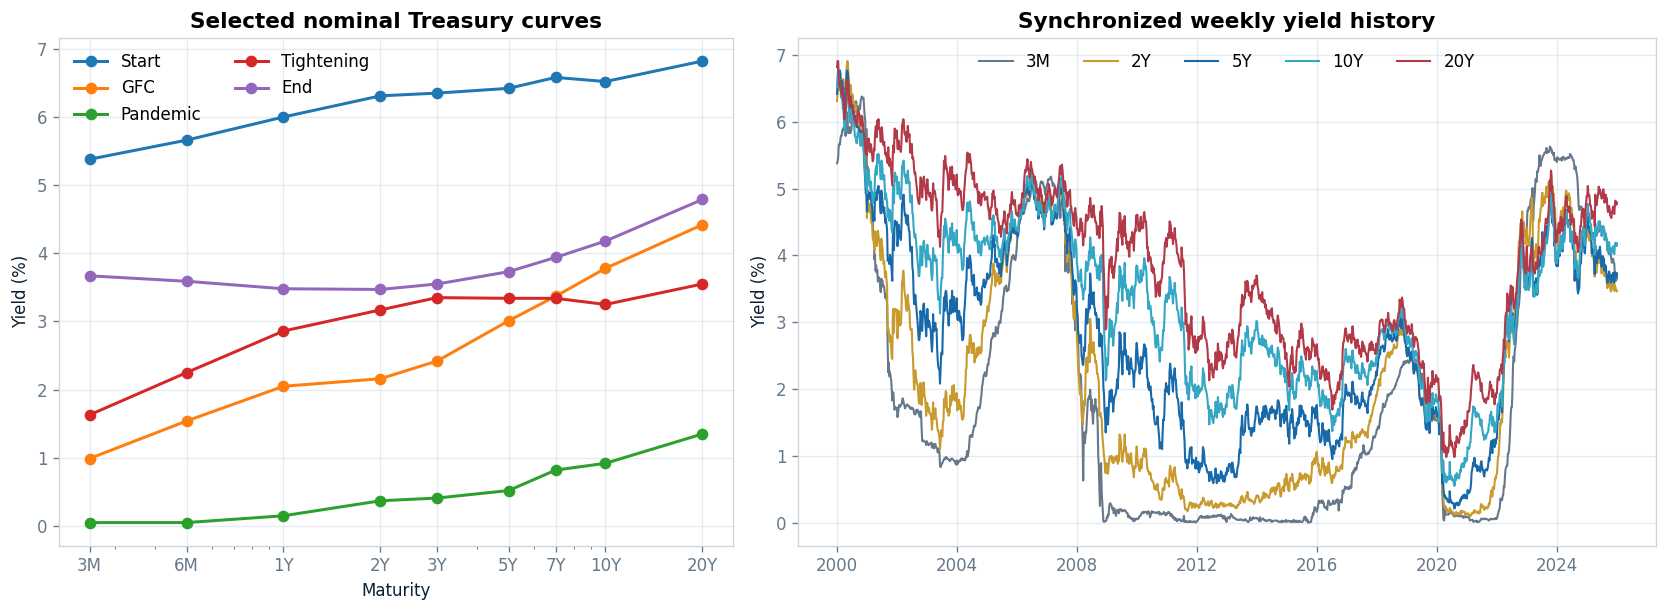

In [ ]:
def nearest_prior_row(frame, target_date):
    target = pd.Timestamp(target_date)
    eligible = frame.index[frame.index <= target]
    if len(eligible) == 0:
        return None
    return frame.loc[eligible[-1]]

curve_dates = OrderedDict([
    ("Start", "2000-01-07"),
    ("GFC", "2008-09-19"),
    ("Pandemic", "2020-03-20"),
    ("Tightening", "2022-06-17"),
    ("End", END_DATE),
])

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), gridspec_kw={"width_ratios": [1.1, 1.4]})
x_maturity = [MATURITY_YEARS[t] for t in CORE_TENORS]
for label, date in curve_dates.items():
    row = nearest_prior_row(weekly_yields, date)
    if row is not None:
        axes[0].plot(x_maturity, row.values, marker="o", linewidth=1.8, label=label)
axes[0].set_xscale("log")
axes[0].set_xticks(x_maturity, CORE_TENORS)
axes[0].set_title("Selected nominal Treasury curves")
axes[0].set_xlabel("Maturity")
axes[0].set_ylabel("Yield (%)")
axes[0].grid(True)
axes[0].legend(ncol=2)

for tenor, color in zip(["3M", "2Y", "5Y", "10Y", "20Y"], [GRAY, GOLD, BLUE, CYAN, RED]):
    axes[1].plot(weekly_yields.index, weekly_yields[tenor], label=tenor, color=color, linewidth=1.25)
axes[1].set_title("Synchronized weekly yield history")
axes[1].set_ylabel("Yield (%)")
axes[1].grid(True)
axes[1].legend(ncol=5, loc="upper center")
fig.tight_layout()
plt.show()


## 3. PCA engine and economic factor identification

For the covariance matrix $\Sigma$ of weekly yield changes, PCA solves $\Sigma v_k=\lambda_k v_k$. The eigenvectors $v_k$ are tenor shock shapes and the projected scores are realized factor shocks in basis points.

PCA signs are mathematically arbitrary. The engine therefore matches the first three components to orthogonal log-maturity templates using maximum absolute cosine similarity, then orients them as:

- **Level:** positive broad parallel move.
- **Slope:** positive long-end move relative to the front end.
- **Curvature:** positive belly move relative to the wings.


In [ ]:
def economic_shape_templates(maturities_years):
    maturities = np.asarray(maturities_years, dtype=float)
    log_maturity = np.log(maturities)
    centered = log_maturity - log_maturity.mean()
    design = np.column_stack([np.ones_like(centered), centered, centered ** 2])
    q, _ = np.linalg.qr(design)
    templates = q.T.copy()

    if templates[0].mean() < 0:
        templates[0] *= -1
    if templates[1, -1] - templates[1, 0] < 0:
        templates[1] *= -1

    belly = templates[2, (maturities >= 1) & (maturities <= 7)].mean()
    wings = templates[2, (maturities <= 0.5) | (maturities >= 10)].mean()
    if belly - wings < 0:
        templates[2] *= -1
    return templates

def fit_yield_curve_pca(changes_bp, maturity_map, standardize=False):
    """Fit, economically label, and sign-orient a full-rank yield-curve PCA."""
    if changes_bp.isna().any().any():
        raise ValueError("PCA input contains missing values.")
    tenors = list(changes_bp.columns)
    maturities = np.array([maturity_map[t] for t in tenors], dtype=float)
    x = changes_bp.astype(float).copy()
    center = x.mean(axis=0)
    scale = x.std(axis=0, ddof=1) if standardize else pd.Series(1.0, index=tenors)
    if (scale <= 0).any():
        raise ValueError("At least one tenor has zero variance.")
    x_model = (x - center) / scale

    model = PCA(n_components=len(tenors), svd_solver="full")
    raw_scores = model.fit_transform(x_model)
    components = model.components_.copy()
    scores = raw_scores.copy()

    templates = economic_shape_templates(maturities)
    similarity = np.abs(components[:3] @ templates.T)
    rows, cols = linear_sum_assignment(-similarity)
    names = ["Level", "Slope", "Curvature"]
    labels = {}
    matched_similarity = {}

    for component_idx, template_idx in zip(rows, cols):
        label = names[template_idx]
        labels[int(component_idx)] = label
        matched_similarity[int(component_idx)] = float(similarity[component_idx, template_idx])
        if np.dot(components[component_idx], templates[template_idx]) < 0:
            components[component_idx] *= -1
            scores[:, component_idx] *= -1

    component_names = [f"PC{i + 1} — {labels.get(i, 'Residual')}" for i in range(len(tenors))]
    loading_table = pd.DataFrame(components.T, index=tenors, columns=component_names)
    score_table = pd.DataFrame(scores, index=x.index, columns=component_names)

    return {
        "model": model,
        "standardized": standardize,
        "center": center,
        "scale": scale,
        "components": components,
        "loadings": loading_table,
        "scores": score_table,
        "explained_variance": model.explained_variance_,
        "explained_ratio": model.explained_variance_ratio_,
        "labels": labels,
        "similarity": matched_similarity,
        "templates": pd.DataFrame(templates.T, index=tenors, columns=names),
        "input": x,
        "model_input": x_model,
    }

core_pca = fit_yield_curve_pca(weekly_changes_bp, MATURITY_YEARS, standardize=False)
print("PCA engine fitted successfully to weekly changes in basis points (covariance specification).")


PCA engine fitted successfully to weekly changes in basis points (covariance specification).


,Component,Economic label,Variance share,Cumulative share,Eigenvalue (bp²)
0,PC1,Level,77.6%,77.6%,881.11
1,PC2,Slope,14.0%,91.7%,159.22
2,PC3,Curvature,5.2%,96.9%,59.18
3,PC4,Residual,1.4%,98.3%,16.17
4,PC5,Residual,0.7%,99.0%,8.07
5,PC6,Residual,0.5%,99.5%,5.13
6,PC7,Residual,0.2%,99.7%,2.61
7,PC8,Residual,0.2%,99.9%,2.15
8,PC9,Residual,0.1%,100.0%,1.45


,PC1 — Level,PC2 — Slope,PC3 — Curvature
3M,+0.125,-0.580,-0.518
6M,+0.163,-0.466,-0.198
1Y,+0.238,-0.404,+0.092
2Y,+0.352,-0.199,+0.454
3Y,+0.393,-0.081,+0.387
5Y,+0.423,+0.094,+0.145
7Y,+0.421,+0.209,-0.072
10Y,+0.390,+0.271,-0.272
20Y,+0.337,+0.334,-0.478


,Component,Assigned shape,Template cosine similarity
0,PC1,Level,0.948
1,PC2,Slope,0.949
2,PC3,Curvature,0.932


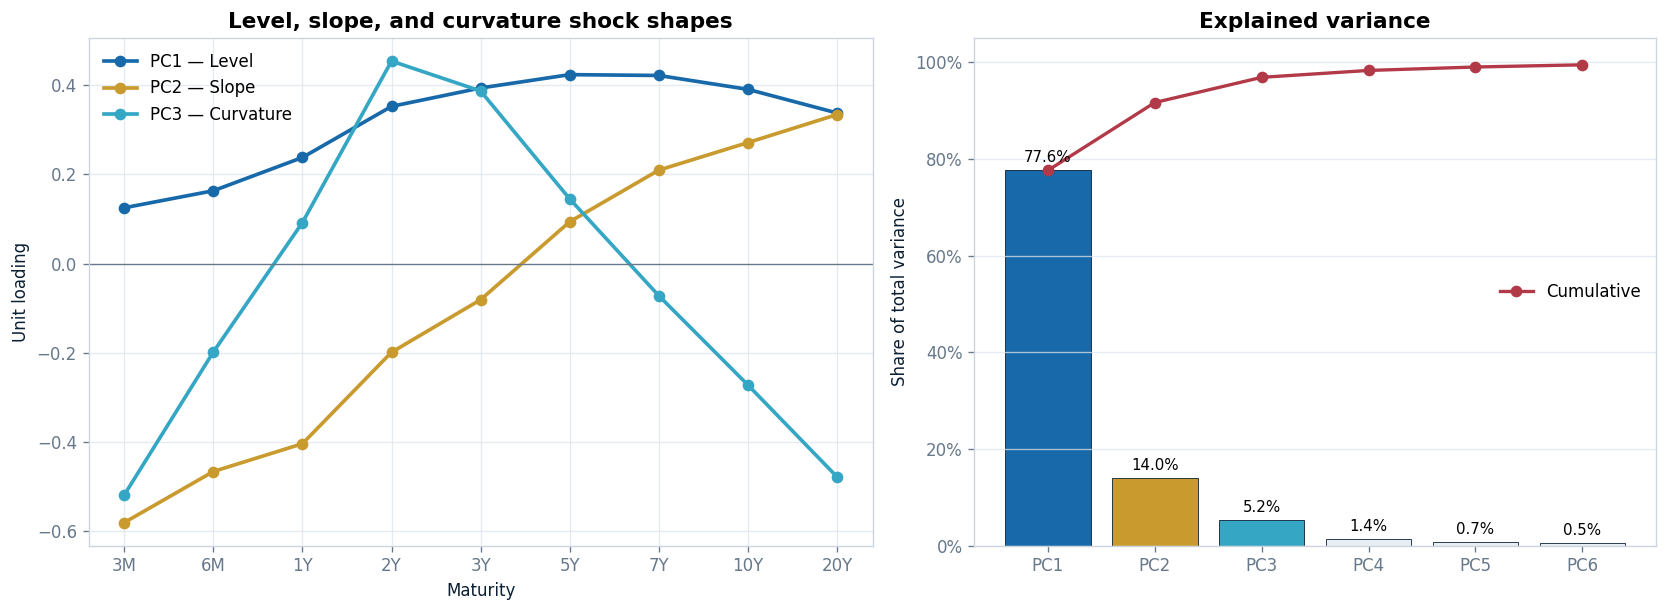

In [ ]:
factor_columns = list(core_pca["loadings"].columns[:3])
explained = pd.DataFrame({
    "Component": [f"PC{i + 1}" for i in range(len(CORE_TENORS))],
    "Economic label": [core_pca["labels"].get(i, "Residual") for i in range(len(CORE_TENORS))],
    "Variance share": core_pca["explained_ratio"],
    "Cumulative share": np.cumsum(core_pca["explained_ratio"]),
    "Eigenvalue (bp²)": core_pca["explained_variance"],
})
display(format_table(
    explained,
    formats={"Variance share": "{:.1%}", "Cumulative share": "{:.1%}", "Eigenvalue (bp²)": "{:.2f}"},
    caption="Full-sample covariance PCA | 2000–2025",
    gradient_subset=["Variance share"],
))

loadings3 = core_pca["loadings"].iloc[:, :3]
display(format_table(
    loadings3,
    formats="{:+.3f}",
    caption="Economically oriented PCA loading vectors",
    gradient_subset=list(loadings3.columns),
))

match_table = pd.DataFrame([
    {
        "Component": f"PC{i + 1}",
        "Assigned shape": core_pca["labels"].get(i, "Residual"),
        "Template cosine similarity": core_pca["similarity"].get(i, np.nan),
    }
    for i in range(3)
])
display(format_table(
    match_table,
    formats={"Template cosine similarity": "{:.3f}"},
    caption="Economic-label validation",
))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), gridspec_kw={"width_ratios": [1.15, 1]})
for column, color in zip(factor_columns, FACTOR_COLORS):
    axes[0].plot(CORE_TENORS, loadings3[column], marker="o", linewidth=2.2, color=color, label=column)
axes[0].axhline(0, color=GRAY, linewidth=0.8)
axes[0].set_title("Level, slope, and curvature shock shapes")
axes[0].set_xlabel("Maturity")
axes[0].set_ylabel("Unit loading")
axes[0].grid(True)
axes[0].legend()

bars = axes[1].bar(explained["Component"][:6], explained["Variance share"][:6] * 100,
                   color=[BLUE, GOLD, CYAN] + [LIGHT] * 3, edgecolor=NAVY, linewidth=0.5)
axes[1].plot(explained["Component"][:6], explained["Cumulative share"][:6] * 100,
             color=RED, marker="o", linewidth=2, label="Cumulative")
axes[1].bar_label(bars, fmt="%.1f%%", padding=3, fontsize=9)
axes[1].set_ylim(0, 105)
axes[1].set_title("Explained variance")
axes[1].set_ylabel("Share of total variance")
axes[1].yaxis.set_major_formatter(PercentFormatter())
axes[1].grid(True, axis="y")
axes[1].legend(loc="center right")
fig.tight_layout()
plt.show()


,Mean (bp),Volatility (bp),1% (bp),99% (bp),Minimum (bp),Maximum (bp)
PC1 — Level,-0.00,29.68,-79.02,78.29,-137.00,155.75
PC2 — Slope,-0.00,12.62,-27.48,42.93,-55.67,105.99
PC3 — Curvature,-0.00,7.69,-19.82,21.96,-47.49,48.45


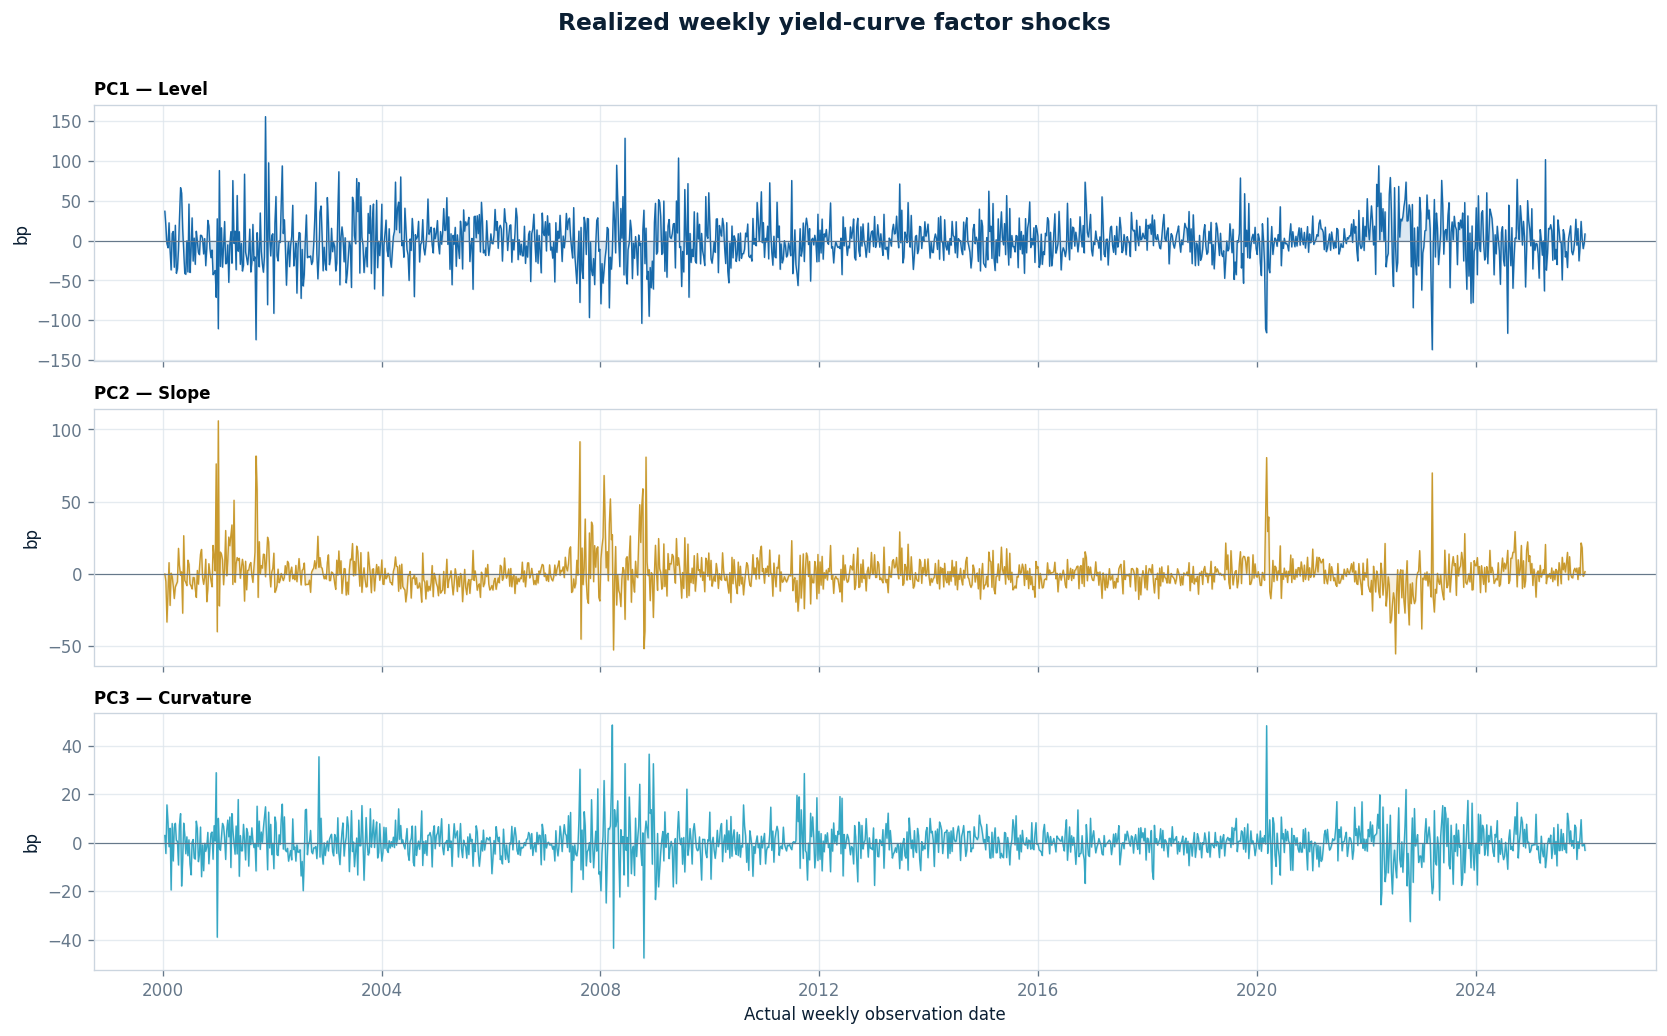

In [ ]:
scores3 = core_pca["scores"].iloc[:, :3]
score_distribution = pd.DataFrame({
    "Mean (bp)": scores3.mean(),
    "Volatility (bp)": scores3.std(ddof=1),
    "1% (bp)": scores3.quantile(0.01),
    "99% (bp)": scores3.quantile(0.99),
    "Minimum (bp)": scores3.min(),
    "Maximum (bp)": scores3.max(),
})
display(format_table(score_distribution, formats="{:.2f}", caption="Realized PCA factor-shock distribution"))

fig, axes = plt.subplots(3, 1, figsize=(14, 8.5), sharex=True)
for ax, column, color in zip(axes, factor_columns, FACTOR_COLORS):
    ax.plot(scores3.index, scores3[column], color=color, linewidth=0.85)
    ax.axhline(0, color=GRAY, linewidth=0.7)
    ax.fill_between(scores3.index, scores3[column], 0, color=color, alpha=0.15)
    ax.set_ylabel("bp")
    ax.set_title(column, loc="left", fontsize=10)
    ax.grid(True)
axes[-1].set_xlabel("Actual weekly observation date")
fig.suptitle("Realized weekly yield-curve factor shocks", fontsize=14, fontweight="bold", color=NAVY, y=1.01)
fig.tight_layout()
plt.show()


## 4. Model controls and specification challenges

A professional PCA implementation should not stop at attractive factor shapes. The following controls test orthogonality, variance accounting, three-factor reconstruction, scaling dependence, and maturity-universe dependence.


In [ ]:
components = core_pca["components"]
model_input = core_pca["model_input"].values
model_mean = core_pca["model"].mean_
scores = core_pca["scores"].values

all_factor_reconstruction = scores @ components + model_mean
three_factor_reconstruction = scores[:, :3] @ components[:3] + model_mean
three_factor_residual = model_input - three_factor_reconstruction

covariance = np.cov(model_input, rowvar=False, ddof=1)
covariance_3pc = (
    components[:3].T
    @ np.diag(core_pca["explained_variance"][:3])
    @ components[:3]
)

diagnostics = pd.DataFrame([
    ["Component orthonormality", np.max(np.abs(components @ components.T - np.eye(len(components)))), "< 1e-10"],
    ["All-factor reconstruction max error", np.max(np.abs(model_input - all_factor_reconstruction)), "< 1e-10 bp"],
    ["Three-factor explained variance", core_pca["explained_ratio"][:3].sum(), "> 90%"],
    ["Three-factor residual MAE", np.mean(np.abs(three_factor_residual)), "Descriptive"],
    ["Three-factor residual RMSE", np.sqrt(np.mean(three_factor_residual ** 2)), "Descriptive"],
    ["Three-factor residual 95th percentile", np.quantile(np.abs(three_factor_residual), 0.95), "Descriptive"],
    ["Covariance Frobenius error", np.linalg.norm(covariance - covariance_3pc, "fro") / np.linalg.norm(covariance, "fro"), "Descriptive"],
    ["Maximum score correlation", np.max(np.abs(scores3.corr().values - np.eye(3))), "< 1e-10"],
], columns=["Diagnostic", "Result", "Threshold / interpretation"])

diagnostics_display = diagnostics.copy()
diagnostics_display.loc[diagnostics_display["Diagnostic"].isin([
    "Three-factor explained variance", "Covariance Frobenius error"
]), "Result"] = diagnostics_display.loc[diagnostics_display["Diagnostic"].isin([
    "Three-factor explained variance", "Covariance Frobenius error"
]), "Result"].map(lambda x: f"{float(x):.2%}")
diagnostics_display.loc[~diagnostics_display["Diagnostic"].isin([
    "Three-factor explained variance", "Covariance Frobenius error"
]), "Result"] = diagnostics_display.loc[~diagnostics_display["Diagnostic"].isin([
    "Three-factor explained variance", "Covariance Frobenius error"
]), "Result"].map(lambda x: f"{float(x):.4f}")
display(format_table(diagnostics_display, caption="Independent PCA validation controls"))

assert diagnostics.iloc[0, 1] < 1e-10
assert diagnostics.iloc[1, 1] < 1e-10
assert core_pca["explained_ratio"][:3].sum() > 0.90
assert diagnostics.iloc[-1, 1] < 1e-10


,Diagnostic,Result,Threshold / interpretation
0,Component orthonormality,0.0000,< 1e-10
1,All-factor reconstruction max error,0.0000,< 1e-10 bp
2,Three-factor explained variance,96.86%,> 90%
3,Three-factor residual MAE,1.3419,Descriptive
4,Three-factor residual RMSE,1.9877,Descriptive
5,Three-factor residual 95th percentile,3.9018,Descriptive
6,Covariance Frobenius error,2.13%,Descriptive
7,Maximum score correlation,0.0000,< 1e-10


In [ ]:
# Challenge 1: correlation PCA (each tenor standardized to unit volatility).
correlation_pca = fit_yield_curve_pca(weekly_changes_bp, MATURITY_YEARS, standardize=True)

# Challenge 2: all 11 maturities after the 30Y H.15 series was reintroduced.
extended_daily_complete = daily_yields.loc[EXTENDED_PANEL_START:END_DATE, ALL_TENORS].dropna(how="any")
extended_weekly = extended_daily_complete.groupby(
    extended_daily_complete.index.to_period(WEEKLY_RULE)
).tail(1)
extended_changes_bp = extended_weekly.diff().dropna() * 100.0
extended_pca = fit_yield_curve_pca(extended_changes_bp, MATURITY_YEARS, standardize=False)

challenge = pd.DataFrame([
    ["Core covariance PCA", "2000–2025", "3M–20Y (9)", len(weekly_changes_bp),
     *core_pca["explained_ratio"][:3], core_pca["explained_ratio"][:3].sum()],
    ["Core correlation PCA", "2000–2025", "3M–20Y (9)", len(weekly_changes_bp),
     *correlation_pca["explained_ratio"][:3], correlation_pca["explained_ratio"][:3].sum()],
    ["Extended covariance PCA", "2006–2025", "1M–30Y (11)", len(extended_changes_bp),
     *extended_pca["explained_ratio"][:3], extended_pca["explained_ratio"][:3].sum()],
], columns=["Specification", "Sample", "Tenor universe", "Weeks", "PC1", "PC2", "PC3", "Top-3 cumulative"])

display(format_table(
    challenge,
    formats={"Weeks": "{:,.0f}", "PC1": "{:.1%}", "PC2": "{:.1%}", "PC3": "{:.1%}",
             "Top-3 cumulative": "{:.1%}"},
    caption="Specification and maturity-universe sensitivity",
))

print(
    "Interpretation control: covariance and correlation specifications both preserve a dominant three-factor structure. "
    "The extended 1M–30Y panel intentionally begins only after the 30Y series reintroduction; no structural gap is filled."
)


,Specification,Sample,Tenor universe,Weeks,PC1,PC2,PC3,Top-3 cumulative
0,Core covariance PCA,2000–2025,3M–20Y (9),"1,356",77.6%,14.0%,5.2%,96.9%
1,Core correlation PCA,2000–2025,3M–20Y (9),"1,356",71.8%,18.9%,5.5%,96.2%
2,Extended covariance PCA,2006–2025,1M–30Y (11),"1,038",64.9%,20.4%,8.3%,93.6%


Interpretation control: covariance and correlation specifications both preserve a dominant three-factor structure. The extended 1M–30Y panel intentionally begins only after the 30Y series reintroduction; no structural gap is filled.


## 5. Regime, rolling-window, and stress diagnostics

Full-sample eigenvectors can conceal regime shifts. The next cells re-estimate PCA within economically distinct periods, monitor five-year rolling variance shares, and identify the largest realized factor weeks without attaching unsupported causal labels.


,Regime,Weeks,PC1,PC2,PC3,Top-3 cumulative
0,2000–2006,364,81.5%,12.5%,3.6%,97.6%
1,GFC | 2007–2009,157,68.4%,20.8%,6.4%,95.6%
2,Post-GFC | 2010–2019,521,86.7%,7.1%,3.2%,97.0%
3,Pandemic | 2020–2021,105,73.4%,18.5%,5.7%,97.6%
4,Tightening | 2022–2025,209,83.1%,10.7%,4.2%,97.9%


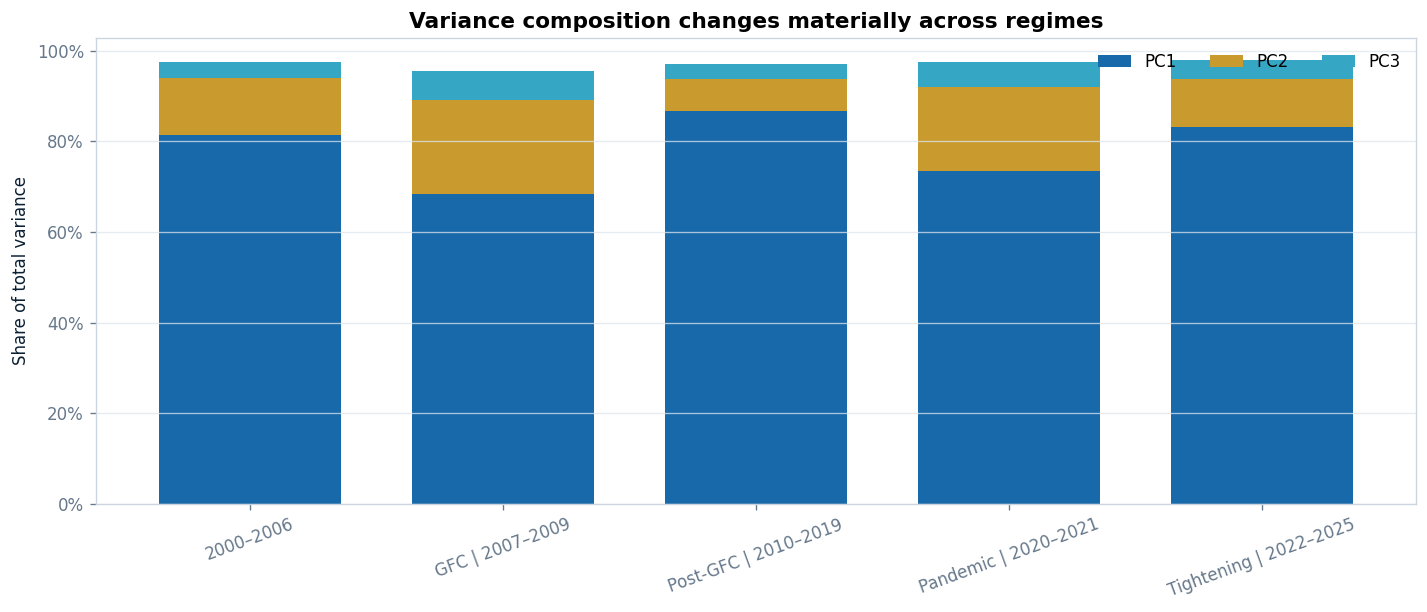

In [ ]:
REGIMES = OrderedDict([
    ("2000–2006", ("2000-01-01", "2006-12-31")),
    ("GFC | 2007–2009", ("2007-01-01", "2009-12-31")),
    ("Post-GFC | 2010–2019", ("2010-01-01", "2019-12-31")),
    ("Pandemic | 2020–2021", ("2020-01-01", "2021-12-31")),
    ("Tightening | 2022–2025", ("2022-01-01", "2025-12-31")),
])

regime_rows = []
for regime, (start, end) in REGIMES.items():
    sample = weekly_changes_bp.loc[start:end]
    result = fit_yield_curve_pca(sample, MATURITY_YEARS, standardize=False)
    regime_rows.append({
        "Regime": regime,
        "Weeks": len(sample),
        "PC1": result["explained_ratio"][0],
        "PC2": result["explained_ratio"][1],
        "PC3": result["explained_ratio"][2],
        "Top-3 cumulative": result["explained_ratio"][:3].sum(),
    })
regime_table = pd.DataFrame(regime_rows)

display(format_table(
    regime_table,
    formats={"Weeks": "{:,.0f}", "PC1": "{:.1%}", "PC2": "{:.1%}", "PC3": "{:.1%}",
             "Top-3 cumulative": "{:.1%}"},
    caption="Regime-specific covariance PCA",
    gradient_subset=["PC1", "PC2", "PC3"],
))

ax = regime_table.set_index("Regime")[["PC1", "PC2", "PC3"]].mul(100).plot(
    kind="bar", stacked=True, color=FACTOR_COLORS, figsize=(12, 5.2), width=0.72
)
ax.set_title("Variance composition changes materially across regimes")
ax.set_ylabel("Share of total variance")
ax.yaxis.set_major_formatter(PercentFormatter())
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=20)
ax.grid(True, axis="y")
ax.legend(loc="upper right", ncol=3)
plt.tight_layout()
plt.show()


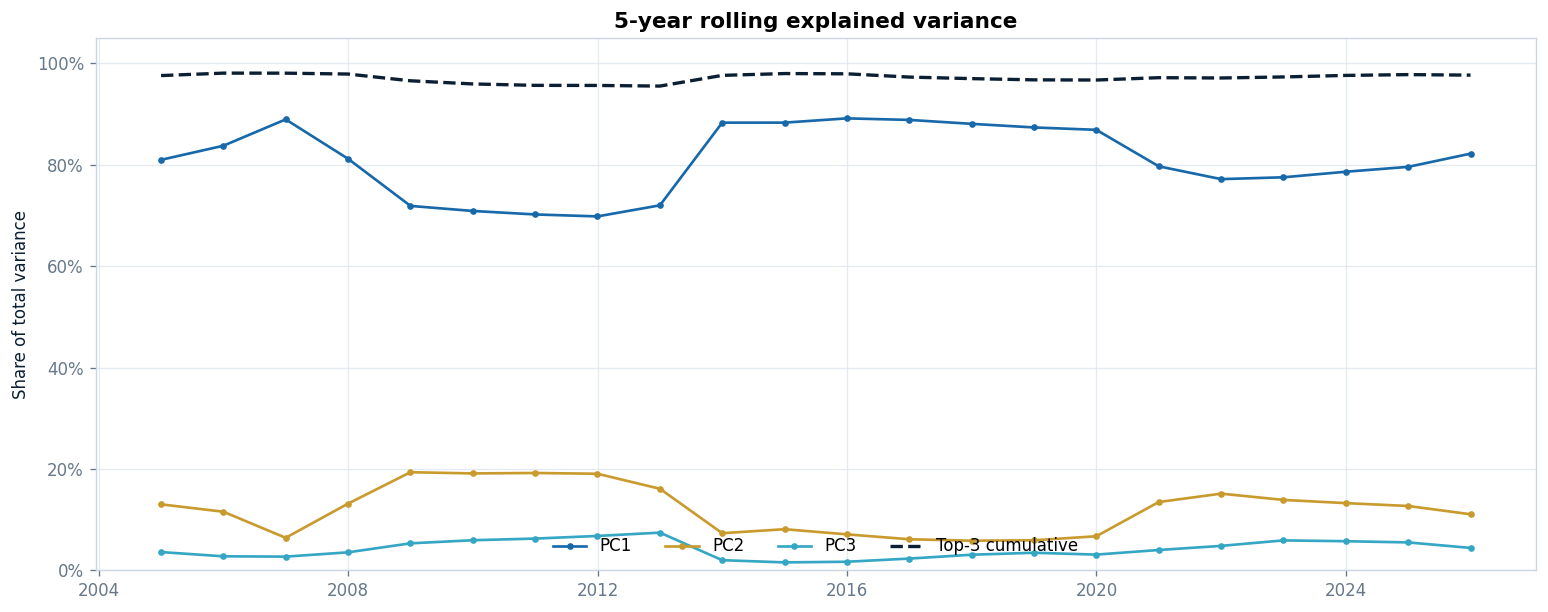

,Minimum,Median,Maximum,Latest
PC1,69.8%,81.1%,89.1%,82.2%
PC2,5.8%,12.9%,19.4%,11.1%
PC3,1.6%,3.8%,7.4%,4.4%
Top-3 cumulative,95.5%,97.3%,98.1%,97.7%


In [ ]:
rolling_rows = []
first_rolling_year = pd.Timestamp(START_DATE).year + ROLLING_WINDOW_YEARS - 1
last_year = pd.Timestamp(END_DATE).year

for end_year in range(first_rolling_year, last_year + 1):
    window_start = f"{end_year - ROLLING_WINDOW_YEARS + 1}-01-01"
    window_end = f"{end_year}-12-31"
    sample = weekly_changes_bp.loc[window_start:window_end]
    if len(sample) < MIN_ROLLING_OBSERVATIONS:
        continue
    result = fit_yield_curve_pca(sample, MATURITY_YEARS, standardize=False)
    rolling_rows.append({
        "Window end": pd.Timestamp(window_end),
        "PC1": result["explained_ratio"][0],
        "PC2": result["explained_ratio"][1],
        "PC3": result["explained_ratio"][2],
        "Top-3 cumulative": result["explained_ratio"][:3].sum(),
    })
rolling_table = pd.DataFrame(rolling_rows).set_index("Window end")

fig, ax = plt.subplots(figsize=(13, 5.2))
for column, color in zip(["PC1", "PC2", "PC3"], FACTOR_COLORS):
    ax.plot(rolling_table.index, rolling_table[column] * 100, marker="o", markersize=3,
            linewidth=1.6, color=color, label=column)
ax.plot(rolling_table.index, rolling_table["Top-3 cumulative"] * 100,
        color=NAVY, linestyle="--", linewidth=2.0, label="Top-3 cumulative")
ax.set_title(f"{ROLLING_WINDOW_YEARS}-year rolling explained variance")
ax.set_ylabel("Share of total variance")
ax.yaxis.set_major_formatter(PercentFormatter())
ax.set_ylim(0, 105)
ax.grid(True)
ax.legend(ncol=4, loc="lower center")
plt.tight_layout()
plt.show()

rolling_summary = pd.DataFrame({
    "Minimum": rolling_table.min(),
    "Median": rolling_table.median(),
    "Maximum": rolling_table.max(),
    "Latest": rolling_table.iloc[-1],
})
display(format_table(rolling_summary, formats="{:.1%}", caption="Rolling-window stability summary"))


In [ ]:
stress_rows = []
for column in factor_columns:
    extreme_dates = scores3[column].abs().nlargest(5).index
    for date in extreme_dates:
        stress_rows.append({
            "Factor": column,
            "Date": date.date(),
            "Factor shock (bp)": scores3.loc[date, column],
            "3M move (bp)": weekly_changes_bp.loc[date, "3M"],
            "2Y move (bp)": weekly_changes_bp.loc[date, "2Y"],
            "10Y move (bp)": weekly_changes_bp.loc[date, "10Y"],
            "20Y move (bp)": weekly_changes_bp.loc[date, "20Y"],
        })
stress_table = pd.DataFrame(stress_rows)
display(format_table(
    stress_table,
    formats={c: "{:+.2f}" for c in stress_table.columns if "(bp)" in c},
    caption="Largest absolute realized factor weeks",
))

print(
    "Risk-use note: these are empirical historical shocks, not standalone VaR. For limit setting or capital, "
    "retain valuation nonlinearities, liquidity horizons, current-position mapping, and independent stress scenarios."
)


,Factor,Date,Factor shock (bp),3M move (bp),2Y move (bp),10Y move (bp),20Y move (bp)
0,PC1 — Level,2001-11-16,+155.75,+12.00,+64.00,+57.00,+47.00
1,PC1 — Level,2023-03-17,-137.00,-49.00,-79.00,-31.00,-14.00
2,PC1 — Level,2008-06-13,+128.65,+14.00,+65.00,+33.00,+19.00
3,PC1 — Level,2001-09-14,-124.49,-63.00,-66.00,-23.00,-7.00
4,PC1 — Level,2024-08-02,-116.38,-9.00,-48.00,-40.00,-34.00
5,PC2 — Slope,2001-01-05,+105.99,-77.00,-55.00,-19.00,-9.00
6,PC2 — Slope,2007-08-17,+91.51,-81.00,-29.00,-13.00,-5.00
7,PC2 — Slope,2001-09-14,+81.60,-63.00,-66.00,-23.00,-7.00
8,PC2 — Slope,2008-10-31,+80.82,-43.00,-1.00,+25.00,+30.00
9,PC2 — Slope,2020-03-06,+80.48,-82.00,-37.00,-39.00,-37.00


Risk-use note: these are empirical historical shocks, not standalone VaR. For limit setting or capital, retain valuation nonlinearities, liquidity horizons, current-position mapping, and independent stress scenarios.


## 6. Dynamic professional interpretation

The following conclusion is generated from the computed results rather than hard-coded factor percentages. It separates empirical findings, model-risk limits, and practical market-risk use.


In [ ]:
pc1, pc2, pc3 = core_pca["explained_ratio"][:3]
cumulative3 = pc1 + pc2 + pc3
residual_share = 1 - cumulative3
residual_mae = float(np.mean(np.abs(three_factor_residual)))
residual_p95 = float(np.quantile(np.abs(three_factor_residual), 0.95))
slope_column = [c for c in factor_columns if "Slope" in c][0]
curvature_column = [c for c in factor_columns if "Curvature" in c][0]
level_column = [c for c in factor_columns if "Level" in c][0]
largest_level_date = scores3[level_column].abs().idxmax().date()
largest_level_shock = scores3.loc[pd.Timestamp(largest_level_date), level_column]
lowest_regime_pc1 = regime_table.loc[regime_table["PC1"].idxmin()]
extended_top3 = extended_pca["explained_ratio"][:3].sum()
similarity_min = min(core_pca["similarity"].values())

conclusion = f"""
### Executive conclusion

1. **Three-factor structure is strongly supported.** Level, slope, and curvature explain **{cumulative3:.1%}** of 2000–2025 weekly curve-change variance ({pc1:.1%}, {pc2:.1%}, and {pc3:.1%}, respectively). Economic-template similarities are all at least **{similarity_min:.3f}**, so the labels are data-supported rather than imposed by sign inspection.

2. **The factor shapes are economically coherent.** The level vector is positive across all maturities; the slope vector moves the long end against the front end; and curvature concentrates the opposing move in the 2Y–3Y belly versus the short and long wings. This supports factor-DV01 aggregation and level/slope/butterfly stress design.

3. **Three factors are efficient but not complete.** The residual share is **{residual_share:.1%}**; three-factor reconstruction produces a mean absolute tenor error of **{residual_mae:.2f} bp** and a 95th-percentile absolute error of **{residual_p95:.2f} bp**. Key-rate sensitivities and localized basis stresses should therefore remain in production controls.

4. **Factor mix is regime-dependent.** PC1 falls to **{lowest_regime_pc1['PC1']:.1%}** in **{lowest_regime_pc1['Regime']}**, while slope and curvature become more material. Static factor limits should be supplemented by rolling calibration, crisis windows, and explicit nonparallel shocks.

5. **Stress history is not Gaussian-looking in the tails.** The largest absolute realized level shock occurs on **{largest_level_date}** at **{largest_level_shock:+.2f} bp** in PCA-score units. Historical extremes should be retained as named-by-date replay scenarios rather than replaced by variance-only limits.

6. **Maturity coverage matters.** Adding 1M and 30Y in the post-2006 extended panel lowers top-three coverage to **{extended_top3:.1%}**, evidencing additional edge/local-curve behavior. Front-end and ultra-long books require tenor-specific residual monitoring beyond the classic three factors.

**Overall assessment:** the model is suitable for yield-curve dimension reduction, factor reporting, historical scenario construction, and hedge diagnostics. It is not, by itself, a pricing curve, a liquidity model, or a complete VaR/stress framework.
"""
display(Markdown(conclusion))



### Executive conclusion

1. **Three-factor structure is strongly supported.** Level, slope, and curvature explain **96.9%** of 2000–2025 weekly curve-change variance (77.6%, 14.0%, and 5.2%, respectively). Economic-template similarities are all at least **0.932**, so the labels are data-supported rather than imposed by sign inspection.

2. **The factor shapes are economically coherent.** The level vector is positive across all maturities; the slope vector moves the long end against the front end; and curvature concentrates the opposing move in the 2Y–3Y belly versus the short and long wings. This supports factor-DV01 aggregation and level/slope/butterfly stress design.

3. **Three factors are efficient but not complete.** The residual share is **3.1%**; three-factor reconstruction produces a mean absolute tenor error of **1.34 bp** and a 95th-percentile absolute error of **3.90 bp**. Key-rate sensitivities and localized basis stresses should therefore remain in production controls.

4. **Factor mix is regime-dependent.** PC1 falls to **68.4%** in **GFC | 2007–2009**, while slope and curvature become more material. Static factor limits should be supplemented by rolling calibration, crisis windows, and explicit nonparallel shocks.

5. **Stress history is not Gaussian-looking in the tails.** The largest absolute realized level shock occurs on **2001-11-16** at **+155.75 bp** in PCA-score units. Historical extremes should be retained as named-by-date replay scenarios rather than replaced by variance-only limits.

6. **Maturity coverage matters.** Adding 1M and 30Y in the post-2006 extended panel lowers top-three coverage to **93.6%**, evidencing additional edge/local-curve behavior. Front-end and ultra-long books require tenor-specific residual monitoring beyond the classic three factors.

**Overall assessment:** the model is suitable for yield-curve dimension reduction, factor reporting, historical scenario construction, and hedge diagnostics. It is not, by itself, a pricing curve, a liquidity model, or a complete VaR/stress framework.


## 7. Sources, governance, and limitations

**Primary official sources**

- [Federal Reserve Board — H.15 Selected Interest Rates](https://www.federalreserve.gov/releases/h15/)
- [FRED — H.15 release series](https://fred.stlouisfed.org/release?rid=18)
- [U.S. Treasury — Treasury yield-curve methodology](https://home.treasury.gov/policy-issues/financing-the-government/interest-rate-statistics/treasury-yield-curve-methodology)
- Series pages follow `https://fred.stlouisfed.org/series/{SERIES_ID}` for the IDs disclosed in the coverage table.

**Governance notes**

- H.15 constant-maturity yields are interpolated by the U.S. Treasury from actively traded, non-inflation-indexed Treasury securities and are quoted on an investment basis.
- FRED data can be revised. The notebook records the retrieval timestamp and SHA-256 of the assembled snapshot; production use should archive the source extract and code version.
- 1M does not cover calendar year 2000. The 30Y H.15 series was discontinued on 2002-02-18 and reintroduced on 2006-02-09; the core model avoids treating any interim proxy as definitionally identical.
- PCA is linear, backward-looking, sample-dependent, and insensitive to portfolio nonlinearities. It should be combined with key-rate DV01/CS01, full revaluation, stress testing, liquidity horizons, and model-performance monitoring as appropriate.
